Prompts are the input instructions or queries given to model to guide its output

# Types of Prompts 
1. Static Prompts
2. Dynamic Prompts

1. Static Prompt Example

In [ ]:
from huggingface_hub import InferenceClient
from dotenv import load_dotenv
import streamlit as st
import os

# Load environment variables
load_dotenv()

# Get Hugging Face API token
hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

# Initialize Hugging Face client
client = InferenceClient(
    api_key=hf_token
)

# Streamlit UI
st.header("Research Assistant")

user_input = st.text_area("Enter your prompt:")

if st.button("Summarize"):

    if user_input.strip() == "":
        st.warning("Please enter some text.")
    
    else:
        try:
            response = client.chat_completion(
                model="meta-llama/Llama-3.1-8B-Instruct",
                messages=[
                    {
                        "role": "user",
                        "content": f"Summarize this:\n\n{user_input}"
                    }
                ],
                max_tokens=20
            )

            result = response.choices[0].message.content

            st.subheader("Summary")
            st.write(result)

        except Exception as e:
            st.error(f"Error: {e}")

2. Dynamic prompt Exmaple

In [ ]:
from huggingface_hub import InferenceClient
from dotenv import load_dotenv
import streamlit as st
import os
from langchain_core.prompts import PromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

# Load environment variables
load_dotenv()

# Get Hugging Face API token
hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

# Initialize Hugging Face client
client = InferenceClient(
    api_key=hf_token
)

# Streamlit UI
st.header("Research Assistant")

paper_input = st.selectbox("Select a research paper:", ["Attention is all you need", "Bert Pretraining of Deep Bidirectional Transformers", "GPT-3: Language Models are Few-Shot Learners"])

style_input = st.selectbox("Select a writing style:", ["Academic", "Informal", "Technical"])

length_input = st.selectbox("Select summary length:", ["Short", "Medium", "Long"])

# Template for the prompt
template = PromptTemplate(
    template = """
Please summarize the following research paper titled {paper} in {style} style and {length} length:
1. Mathematical Detials:
- Include relevant equations and mathematical concepts.
- Provide explanations for the equations and their significance in the context of the paper.
2. Analogies:
- Use analogies to explain complex concepts in a more relatable way.
- Provide examples to illustrate the analogies and enhance understanding.
Ensure the summary is clear, accurate and aligned with the provided style and length
""",   input_variables=["paper", "style", "length"]
)

## Fill the placegholdes
prompt = template.invoke({"paper": paper_input, "style": style_input, "length": length_input})

if st.button("Summarize"):
    try:
        response = client.chat_completion(
            model="meta-llama/Llama-3.1-8B-Instruct",
            messages=[
                {
                    "role": "user",
                    "content": prompt.text
                }
            ],
            max_tokens=300
        )

        result = response.choices[0].message.content

        st.subheader("Summary")
        st.write(result)

    except Exception as e:
        st.error(f"Error: {e}")

### Why use prompts over f string
1. Default Validation
2. Reusable
3. LangChain Ecosystem

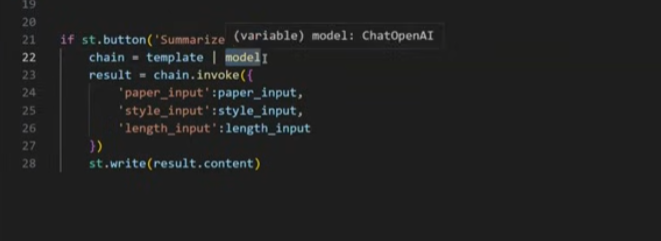

## Types of messages
1. System message
2. Human message
3. AI message

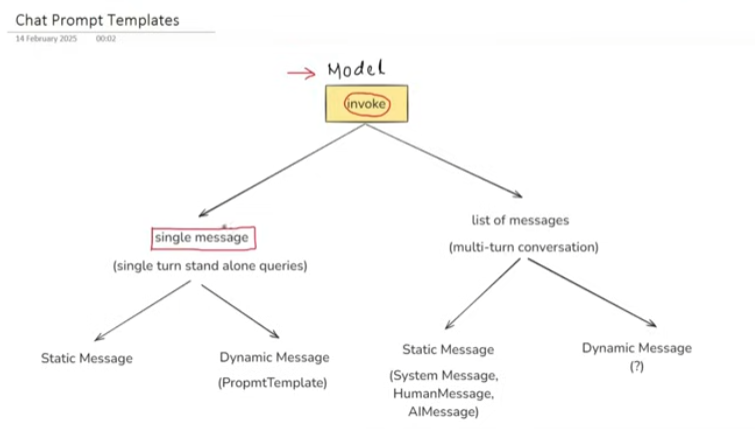

### ChatPromptTemplate


example given in the chatprompttemplate.py

## Message Placeholder

A messagePlaceholder in langchain is a special placeholder used inside a ChatPromptTemplate to dynamically insert chat history ot a list of messages at runtime